### Baseline Classifiers

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load cleaned data
df = pd.read_csv('../data/vocal_gender_features_cleaned.csv')

In [3]:
# Split features and target
X = df.drop('label', axis=1)
y = df['label']

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [5]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True)
}


Logistic Regression
              precision    recall  f1-score   support

      Female       0.99      0.99      0.99      1569
        Male       0.99      0.99      0.99      2952

    accuracy                           0.99      4521
   macro avg       0.99      0.99      0.99      4521
weighted avg       0.99      0.99      0.99      4521



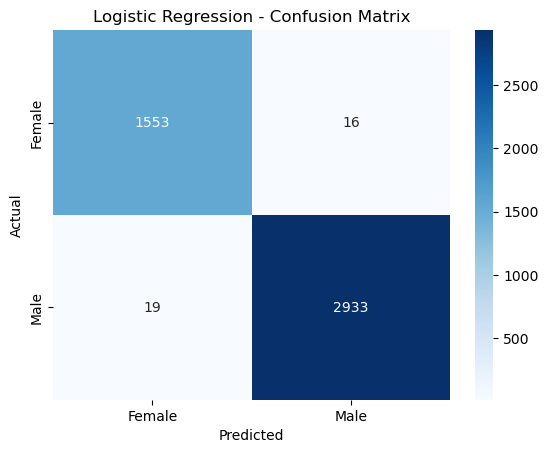


Random Forest
              precision    recall  f1-score   support

      Female       0.99      0.99      0.99      1569
        Male       0.99      1.00      1.00      2952

    accuracy                           0.99      4521
   macro avg       0.99      0.99      0.99      4521
weighted avg       0.99      0.99      0.99      4521



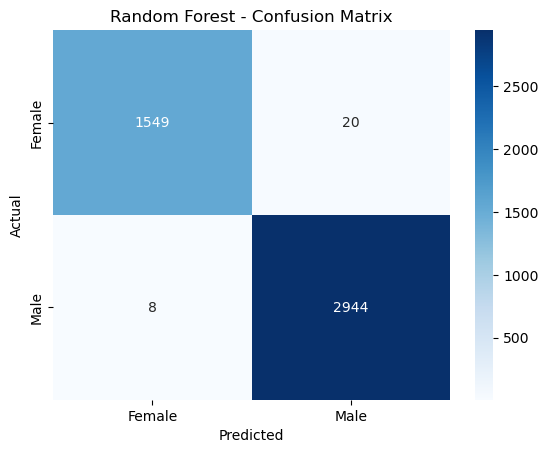


SVM
              precision    recall  f1-score   support

      Female       1.00      1.00      1.00      1569
        Male       1.00      1.00      1.00      2952

    accuracy                           1.00      4521
   macro avg       1.00      1.00      1.00      4521
weighted avg       1.00      1.00      1.00      4521



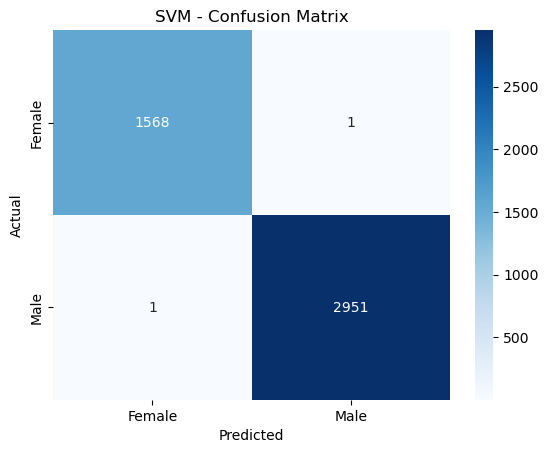

In [7]:
# Train and evaluate each model
for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred, target_names=["Female", "Male"]))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Female", "Male"], yticklabels=["Female", "Male"])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### Hyperparameter Tuning

In [8]:
from sklearn.model_selection import GridSearchCV

In [9]:
# 1. Random Forest Tuning
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, rf_params, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF F1 Score:", grid_rf.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best RF F1 Score: 0.9962326005953178


In [10]:
# 2. SVM Tuning
svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

svm = SVC()
grid_svm = GridSearchCV(svm, svm_params, cv=3, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM F1 Score:", grid_svm.best_score_)

Best SVM Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM F1 Score: 0.9994195957905571


### Neural Network Classifier

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score

In [13]:
# Build model
nn_model = Sequential([
    Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

c:\Users\shubh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Compile
nn_model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])


In [15]:
# Train
history = nn_model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9082 - loss: 0.2329 - val_accuracy: 0.9972 - val_loss: 0.0117
Epoch 2/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9956 - loss: 0.0154 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 3/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9974 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 4/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9978 - loss: 0.0066 - val_accuracy: 0.9991 - val_loss: 0.0023
Epoch 5/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9995 - loss: 0.0043 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 6/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9985 - loss: 0.0029 - val_accuracy: 0.9995 - val_loss: 0.0018
Epoch 7/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9986 - loss: 0.0047 - val_accuracy: 0.9991 - val_loss: 0.0026
Epoch 8/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9999 - loss: 0.0011 - val_accuracy: 0.

In [16]:
# Evaluate
y_pred_nn = nn_model.predict(X_test_scaled).round()
print("NN Accuracy:", accuracy_score(y_test, y_pred_nn))

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
NN Accuracy: 0.9993364299933643


In [17]:
import joblib

# Save best model and scaler
joblib.dump(grid_rf.best_estimator_, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and Scaler saved successfully.")


Model and Scaler saved successfully.
